# Описание задачи
Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных. 

Чтобы бороться с оттоком, отдел по работе с клиентами «Культуриста-датасаентиста» перевёл в электронный вид множество клиентских анкет. Моя задача — провести анализ и подготовить план действий по удержанию клиентов. 

Цель исследования: 
* научиться прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
* сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
* проанализировать основные признаки, наиболее сильно влияющие на отток;
* сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:
 * 1) выделить целевые группы клиентов;
 * 2) предложить меры по снижению оттока;
 * 3) определить другие особенности взаимодействия с клиентами.

## Загрузка данных

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage 
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/datasets/gym_churn.csv')
display(df)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


In [3]:
# приведем названия столбцов к нижнему регистру
df.columns = df.columns.str.lower()
display(df.columns)

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')

## Исследовательский анализ данных (EDA)

### Изучение датасета

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

None

In [5]:
display(df['month_to_end_contract'].value_counts())

1.0     2207
6.0      645
12.0     524
11.0     181
5.0      130
10.0      82
9.0       73
4.0       58
8.0       38
7.0       25
3.0       23
2.0       14
Name: month_to_end_contract, dtype: int64

In [6]:
df['month_to_end_contract'] = df['month_to_end_contract'].astype('int')
display(df.info())
display('Дубликатов: ', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   int64  
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

None

'Дубликатов: '

0

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
near_location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


Явных дубликатов нет. Привели стобец *month_to_end_contract* к типу *int*. Данные равномерные, явных выбросов нет, стандартные отклонения невелики.

### Средние значения признаков в двух группах — тех, кто ушел в отток и тех, кто остался

In [8]:
display(df.groupby('churn').mean().T)

churn,0,1
gender,0.510037,0.510839
near_location,0.873086,0.768143
partner,0.534195,0.355325
promo_friends,0.353522,0.183789
phone,0.903709,0.902922
contract_period,5.747193,1.728558
group_visits,0.464103,0.268615
age,29.976523,26.989632
avg_additional_charges_total,158.445715,115.082899
month_to_end_contract,5.283089,1.662582


**В полях - чем ближе среднее значение к единице, тем больше клиентов с этим признаком.**
* Пол не влияет на отток/приток;
* Чаще остаются клиенты, которые живут/работают рядом с фитнес-клубом;
* Удержание клиентов выше, если они попали в фитнес-клуб по партнёрской программе;
* Клиенты, которые пришли по акции остаются чаще;
* Нет никакого влияния на то оставил в анкете свой телефон клиент или нет;
* Клиенты, которые покупают абонементы на 6 мес и год, реже уходят;
* Посещение групповых занятий влияет на удержание;
* Средний возраст не сильно отличается в обеих категориях;
* Время с момента первого посещения постоянного клиента - 5 мес, а ушедших клиентов - 1 мес;
* Среди клиентов, которые остались, число посещений больше, чем у ушедших;
* В последний месяц у ушедших клиентов посещаемость ниже.

### Столбчатые гистограммы и распределения признаков для тех, кто ушёл (отток) и тех, кто остался (не попали в отток)

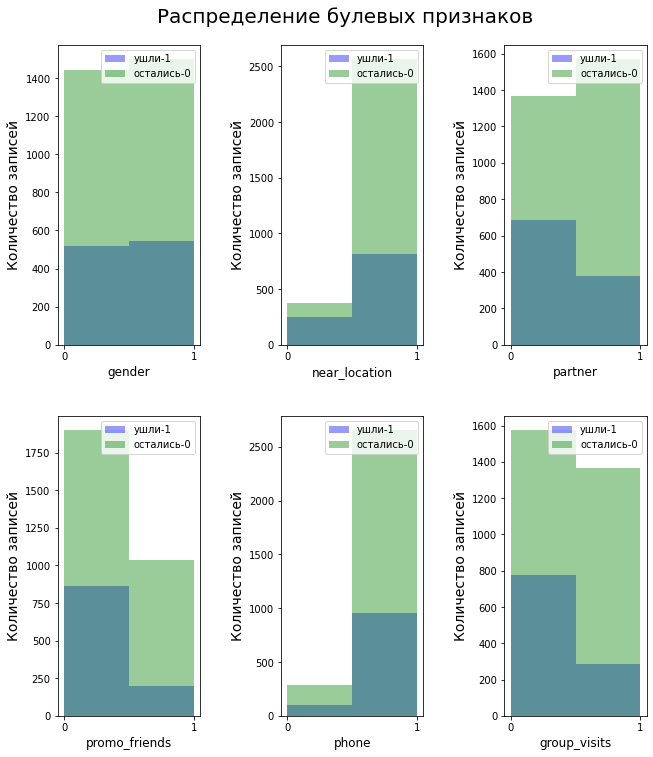

In [9]:
bool_tag = ['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'group_visits']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10,11))
axes_list = [item for sublist in axes for item in sublist]
fig.tight_layout(pad=5.0)
fig.suptitle('Распределение булевых признаков', fontsize=20)
for feature in bool_tag:
    ax = axes_list.pop(0)
    sns.distplot(df.query('churn == 1')[feature].astype(int), bins=2, ax=ax, kde=False, color='b',label='ушли-1')
    sns.distplot(df.query('churn == 0')[feature].astype(int), bins=2, ax=ax, kde=False, color='g',label='остались-0')
    ax.set_xticks([0,1])
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Количество записей', fontsize=14)
    ax.legend()

Проанализировав данные, можно сделать выводы что сильно влияет на отток клиентов:
* Доля оттока у женщин и мужчин почти одинаковая
* Близость проживания оказывает очень важную роль 
* Партнерская программа тоже сильно влияет на сохранение клиентов
* Тех кто участвовал в акции сильно меньше, но при этом доля оставшихся в них гораздо выше
* Телефон в анкете не влияет особо на отток
* Посещение групповых занятий сильно влияет на сохранение клиентов

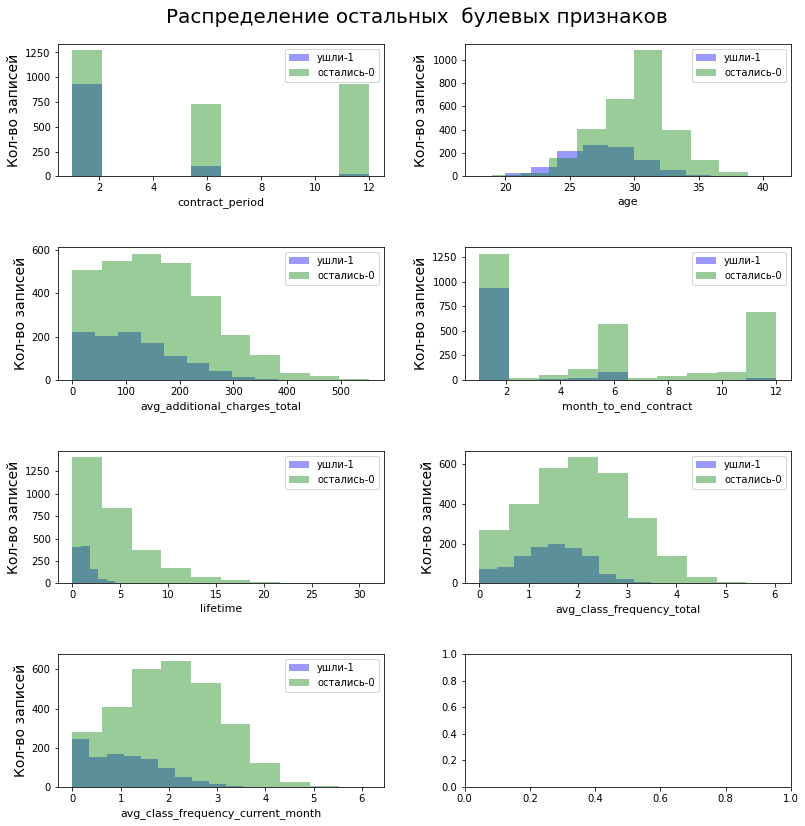

In [10]:
integ_tag = ['contract_period', 'age', 'avg_additional_charges_total', 'month_to_end_contract', 
       'lifetime', 'avg_class_frequency_total', 'avg_class_frequency_current_month']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12,12))
axes_list = [item for sublist in axes for item in sublist]
fig.tight_layout(pad=5.0)
fig.suptitle('Распределение остальных  булевых признаков', fontsize=20)
for feature in integ_tag:
    ax = axes_list.pop(0)
    sns.distplot(df.query('churn == 1')[feature], bins=10, ax=ax, kde=False, color='b',label='ушли-1')
    sns.distplot(df.query('churn == 0')[feature], bins=10, ax=ax, kde=False, color='g',label='остались-0')
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Кол-во записей', fontsize=14)
    ax.legend()

Проанализировав данные, можно сделать выводы что сильно влияет на отток клиентов:
* Чем дольше абонемент, тем у этих клиентов отток меньше
* До возраста 25-26 лет большая часть склонна уйти, но дальше чем старше клиенты тем склонность остаться сильнее
* Траты на доп. услуги слабо влияют на отток
* Основной отток у тех клиентов у кого остался 1 месяц абонемента
* Чем дольше клиент пользуется залом, тем меньше отток
* У тех кто ходит до 2 раз в неделю доли оттока примерно одинаковые, после 3 посещений в неделю доля оттока околонулевая
* Чем чаще клиент ходил в клуб за последний месяц, тем и отток меньше

### Матрица корреляций

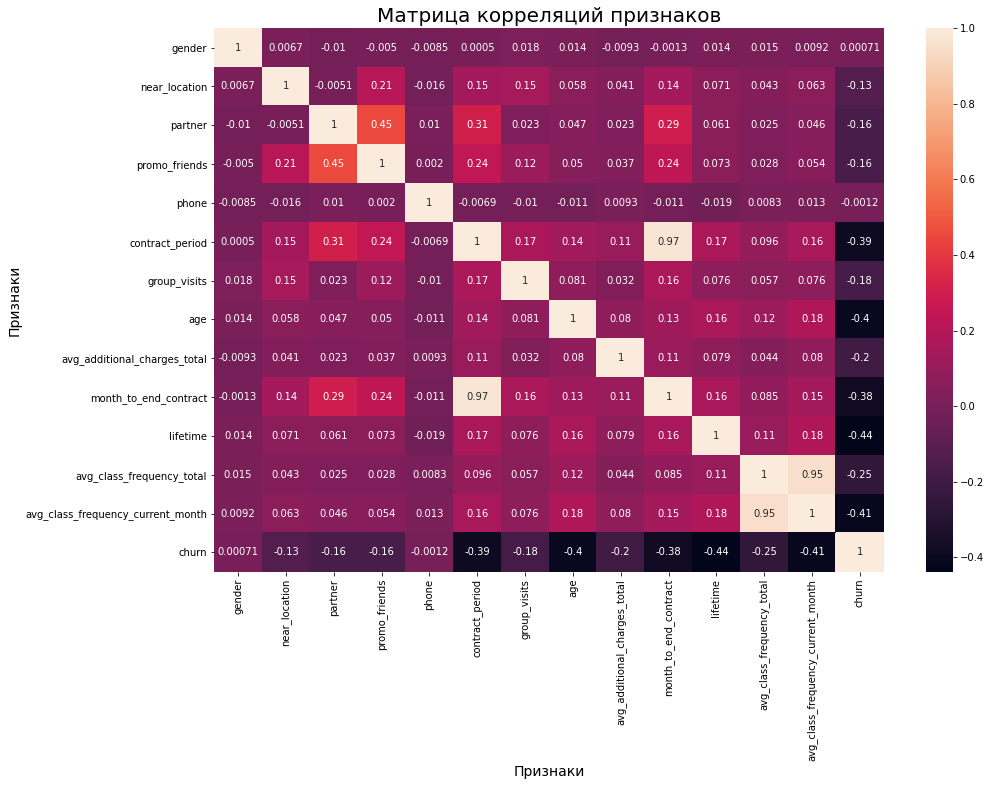

In [11]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot = True, square=False)
plt.title('Матрица корреляций признаков', fontsize = 20)
plt.xlabel('Признаки', fontsize = 14)
plt.ylabel('Признаки', fontsize = 14)
plt.show()

Общая картина похожа на, ту которая в пункте 2.2, однако по карте видно, что 'partner', 'group_visits', 'promo_friends' - оказывают не такое сильное влияние, а влияение 'age' наоборот было недооценено.

Также на матрице корреляции видно две зависимости:

* Срок до окончания текущего действующего абонемента *month_to_end_contract* и длительность текущего абонемента *contract_period*
* Средняя частота посещений в неделю за все время с начала действия абонемента; *avg_class_frequency_total* и средняя частота посещений в неделю за предыдущий месяц *avg_class_frequency_current_month*

### Вывод

Данные целостные, явных пропусков и дубликатов нет. Был изменен тип данных в нужном столбце, названия всех столбцов приведены к нижнему регистру. В ходе EDA анализа было проделано и установлено:
* Все признаки емеют обратную корреляцию с целевой переменной (то есть - чем сильнее признак, тем слабее отток клиентов)
* Есть 5 признаков со средней корреляцией, 6 признаков с слабой корреляцией и 2 почти никак не влияющих.
* Есть 2 пары признаков которые очень сильно коррелируют между собой

## Модель прогнозирования оттока клиентов

### Разбиение данных на обучающую и валидационную выборку

In [12]:
X = df.drop('churn', axis=1)
y = df['churn'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_st = scaler.transform(X_train) 
X_test_st = scaler.transform(X_test) 

### Модели "Логистическая регрессия" и "Случайный лес"

In [13]:
model_lr = LogisticRegression(random_state=0)
model_lr.fit(X_train_st, y_train)
pred_lr = model_lr.predict(X_test_st)

print('Модель прогнозирования - Линейная регрессия')
print('Доля правильных ответов:', round(accuracy_score(y_test, pred_lr), 3))
print('Точность:', round(precision_score(y_test, pred_lr), 3))
print('Полнота:', round(recall_score(y_test, pred_lr), 3))

Модель прогнозирования - Линейная регрессия
Доля правильных ответов: 0.922
Точность: 0.854
Полнота: 0.828


In [14]:
model_rf = RandomForestClassifier(random_state=0, n_estimators=100)
model_rf.fit(X_train_st, y_train)
pred_rf = model_rf.predict(X_test_st)

print('Модель прогнозирования - Случайный лес')
print('Доля правильных ответов:', round(accuracy_score(y_test, pred_rf), 3))
print('Точность:', round(precision_score(y_test, pred_rf), 3))
print('Полнота:', round(recall_score(y_test, pred_rf), 3))

Модель прогнозирования - Случайный лес
Доля правильных ответов: 0.915
Точность: 0.839
Полнота: 0.813


### Оценка метрик

Доля правильных ответов accuracy выше у модели **LogisticRegression** - 0.922;

Точность precision выше у модели **LogisticRegression** - 0.854;

Полнота данных recall больше у модели **LogisticRegression** - 0.828;

Обе модели показали себя хорошо, но с небольшим отрывом результат метрик LogisticRegression после обучения - лучше. Именно она лучше подойдет для прогнозирования оттока клиентов.

## Кластеризация клиентов

### Стандартизация данных

In [15]:
X_sc = scaler.fit_transform(X)
linked = linkage(X_sc, method = 'ward') 

### Матрица расстояний и дендрограмма

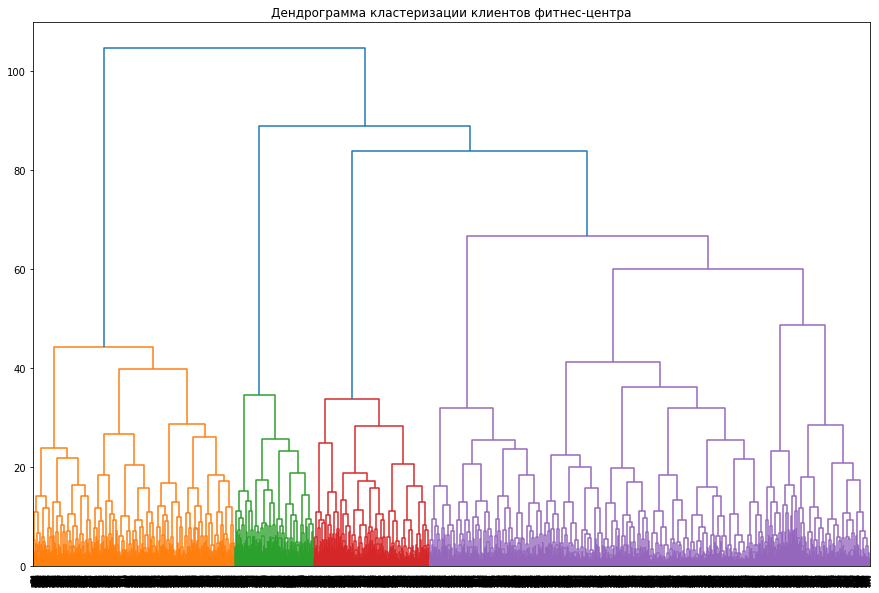

In [16]:
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Дендрограмма кластеризации клиентов фитнес-центра')
plt.show() 

Видим по дендрограмме 5 кластеров клиентов.

### Кластеризации по алгоритму K-Means и прогнозирование кластеров клиентов

In [17]:
km = KMeans(n_clusters = 5, random_state=0)
labels = km.fit_predict(X_sc)
df['cluster_km'] = labels
display(df)

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn,cluster_km
0,1,1,1,1,0,6,1,29,14.227470,5,3,0.020398,0.000000,0,1
1,0,1,0,0,1,12,1,31,113.202938,12,7,1.922936,1.910244,0,0
2,0,1,1,0,1,1,0,28,129.448479,1,2,1.859098,1.736502,0,3
3,0,1,1,1,1,12,1,33,62.669863,12,2,3.205633,3.357215,0,0
4,1,1,1,1,1,1,0,26,198.362265,1,3,1.113884,1.120078,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12,8,2.284497,2.349070,0,0
3996,0,1,0,0,1,1,1,29,68.883764,1,1,1.277168,0.292859,1,3
3997,1,1,1,1,1,12,0,28,78.250542,11,2,2.786146,2.831439,0,0
3998,0,1,1,1,1,6,0,32,61.912657,5,3,1.630108,1.596237,0,0


### Средние значения признаков по кластерам

In [18]:
display(df.groupby(['cluster_km']).mean().T)

cluster_km,0,1,2,3,4
gender,0.502970,0.522078,0.495050,0.485737,0.559666
near_location,0.959406,0.862338,0.000000,1.000000,0.976134
partner,0.783168,0.470130,0.463366,0.350238,0.356802
promo_friends,0.574257,0.306494,0.079208,0.240095,0.230310
phone,1.000000,0.000000,1.000000,1.000000,0.998807
contract_period,10.889109,4.787013,2.352475,1.948494,2.669451
group_visits,0.542574,0.425974,0.215842,0.341521,0.473747
age,29.982178,29.301299,28.477228,28.167987,30.125298
avg_additional_charges_total,160.761016,143.957664,135.457501,131.622204,161.657905
month_to_end_contract,9.954455,4.475325,2.198020,1.856577,2.459427


In [19]:
display(df.groupby(['cluster_km'])['gender'].count())

cluster_km
0    1010
1     385
2     505
3    1262
4     838
Name: gender, dtype: int64

### Распределение признаков для кластеров

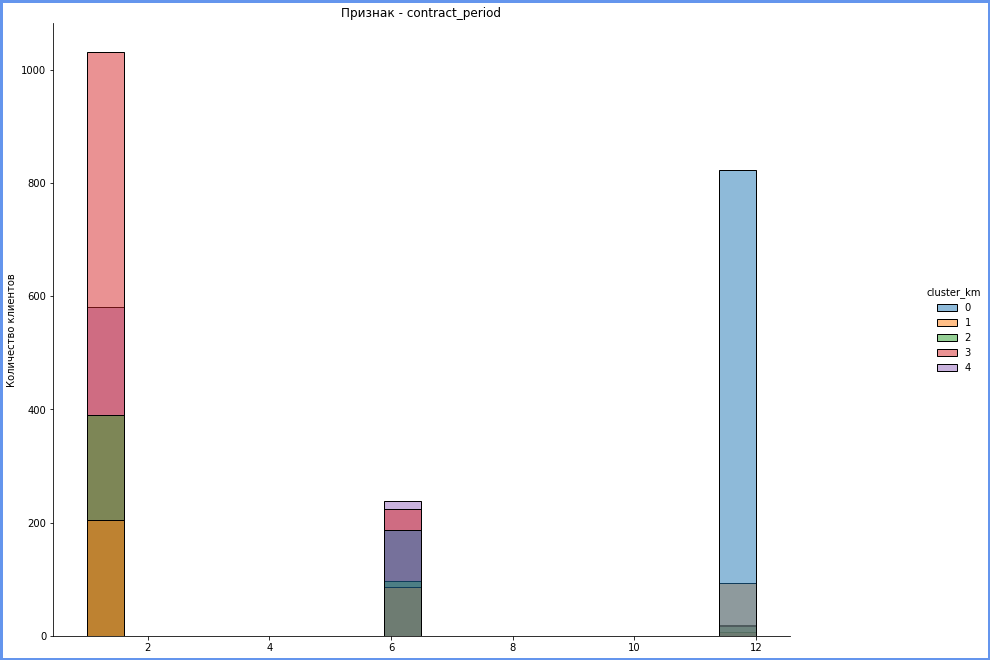

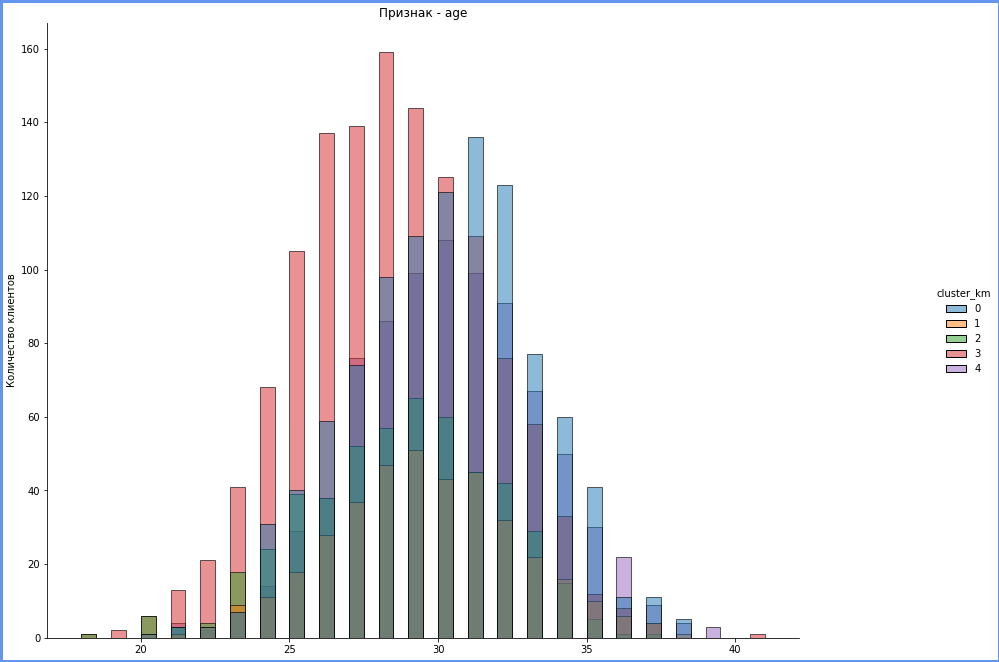

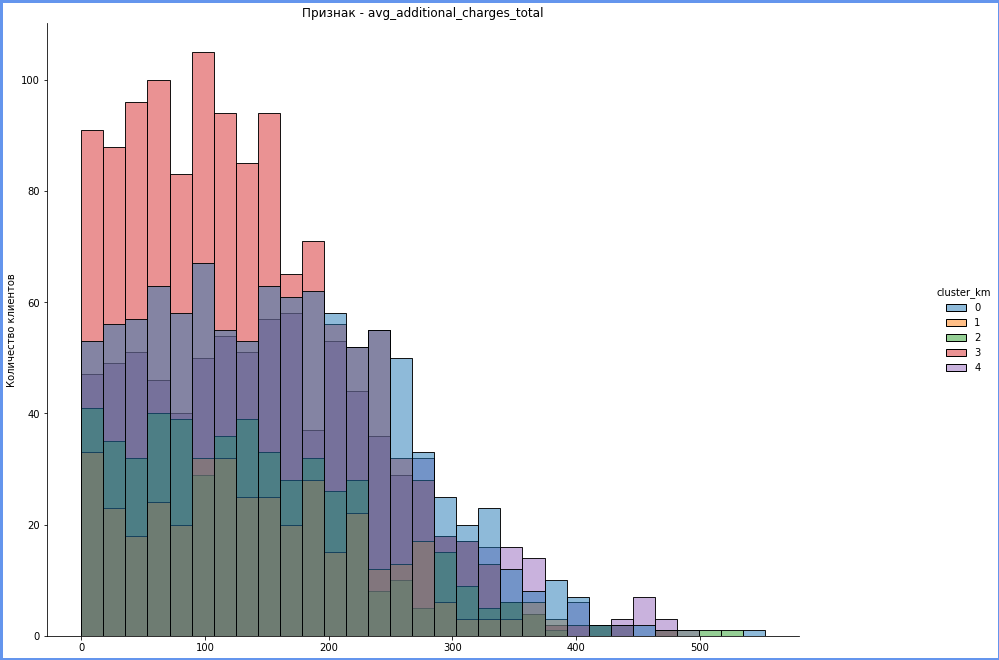

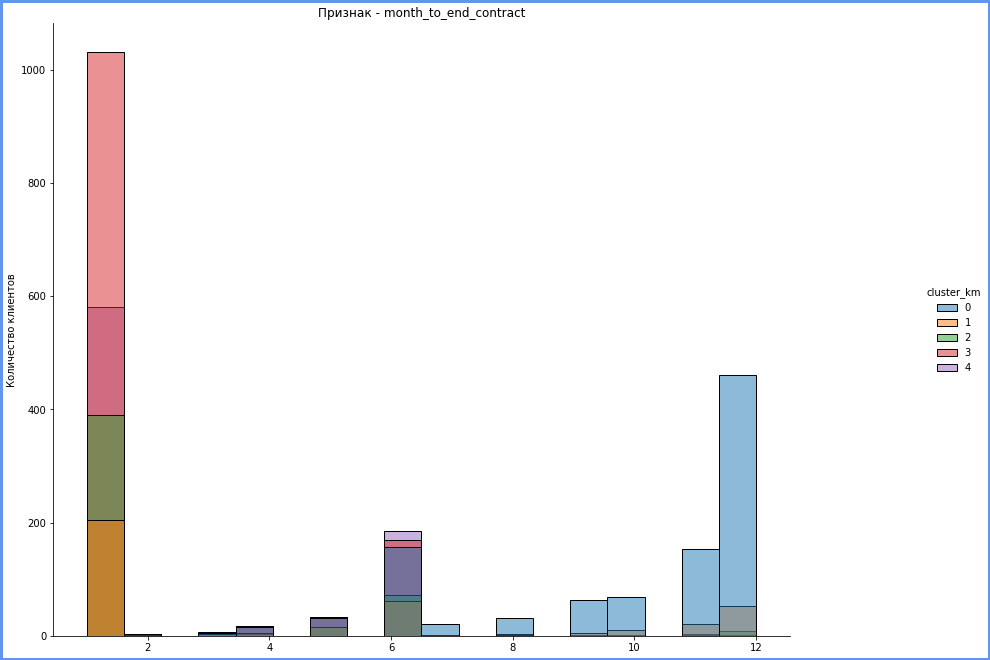

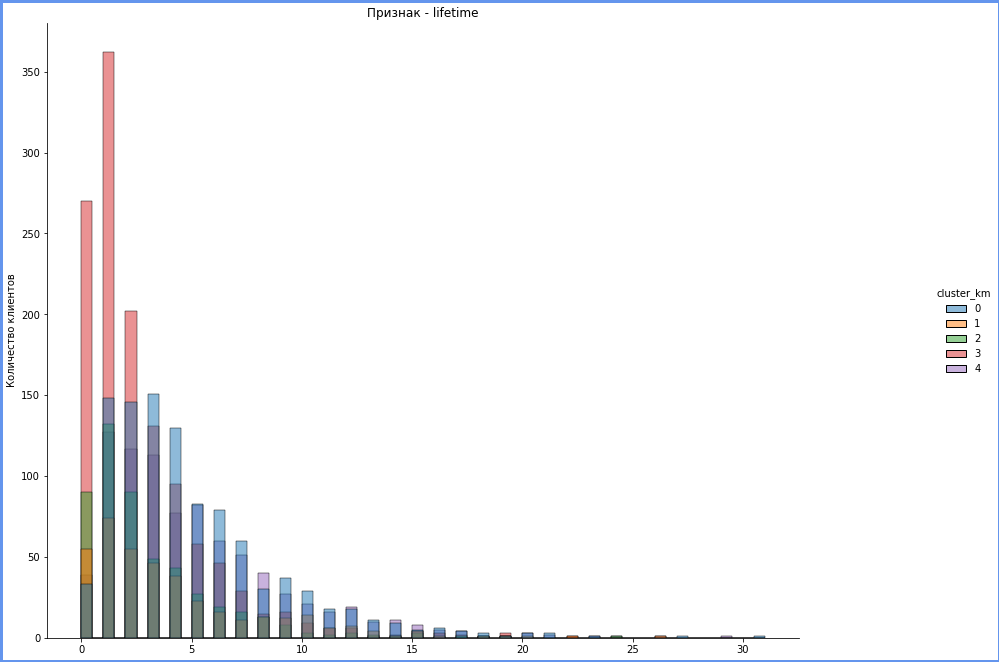

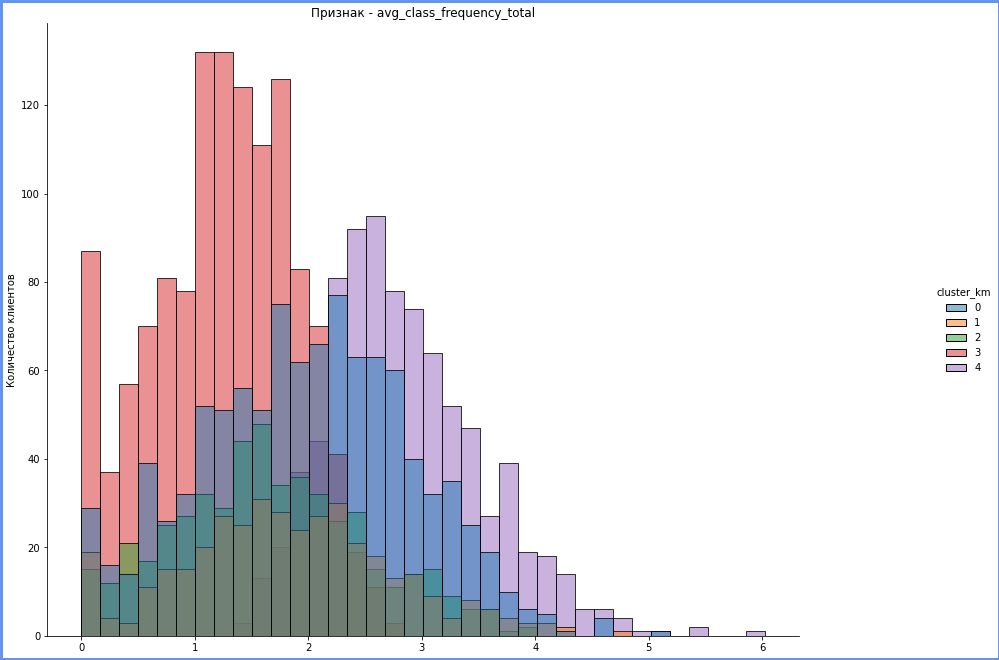

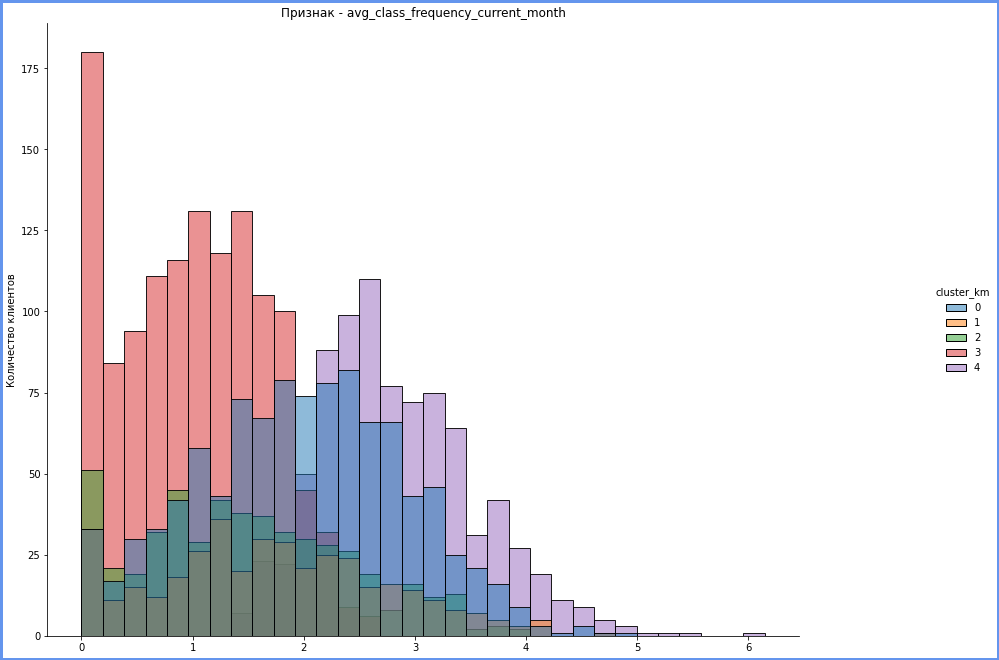

In [20]:
for f in integ_tag:
    g = sns.displot(df, x=df[f], hue='cluster_km', palette="tab10", kind='hist' )
    plt.title(f'Признак - {f}')
    plt.ylabel("Количество клиентов")
    plt.xlabel("")
    g.fig.set_figwidth(15)
    g.fig.set_figheight(10)
    g.fig.patch.set_linewidth(5)
    g.fig.patch.set_edgecolor('cornflowerblue')

    

Из графиков видно:
* Абонементы продаются на периоды 1,6,12 месяцев. *Кластер 0* состоит преимущественно из 12-ти месячных абонементов, и в нем нет тех у кого абонемент длится 1 месяц и почти нет 6-ти месячных
* *Кластер 3* преимущественно состоит из тех кому 30 лет и меньше, а *кластер 0* кому больше 30-ти лет
* В *кластере 3* в основом посетители ходили 2 месяца и меньше, в *кластаре 0* более 2-х месяцев
* В *кластере 0* посетители ходят в основном ОТ 2 раз в неделю, в *кластере 3* в основном ДО 2-х раз

### Доля оттока в кластерах

In [21]:
leavers = df.query('churn==1').groupby('cluster_km')['churn'].count() / df.query('churn==1')['churn'].count()
display(leavers)  

cluster_km
0    0.026390
1    0.097078
2    0.211122
3    0.611687
4    0.053723
Name: churn, dtype: float64

### Вывод

Самый большой отток получился в *3-м кластере* (61.16%), а самый маленький из *кластера 0* (2.63%).

Выводы по кластерам:

**Кластер 0**
Живут в основном недалеко от фитнес-клуба, занимаются по программе лояльности. Часто пользуются акцией и посещают групповые занятия. Покупают абонемент на 1 год и ходят более 2 раз в неделю.

**Кластер 1**
Живут в основном недалеко от фитнес-клуба, тоже часто занимаются по программе лояльности и пользуются акцией, но меньше чем в *Кластере 0*. Часто НЕ указывают номер телефона, абонемент предпочитают покупать на полгода. Посещают клуб около 2-х раз в неделю.

**Кластер 2**
Живут далеко от фитнес-клуба, как и в *кластере 1* занимаются по программе лояльности, но почти не пользуются акцией. Абонемент покупают на 2-3 месяца, редко ходят на групповые занятия. В неделю в среднем 1-2 посещения.

**Кластер 3**
ВСЕ живут рядом с клубом, при этом только треть занимается по программе лояльности. Абонемент в среднем на 2 месяца, и всего треть ходит на групповые занятия. Примерно 1 посещение в неделю.

**Кластер 4**
Живут в основном недалеко от фитнес-клуба, треть занимается по программе лояльности и четверть пользуются акцией. Абонемент продолжительностью 2-3 месяца, половина ходит на групповые занятия и посещают клуб 3 раза в неделю.

##  Выводы и базовые рекомендации по работе с клиентам

### Вывод
В ходе исследования загрузили данные датасета и подготовили их к анализу, приведя названия к нижнему регистру, изменив тип данных в столбце и проверив данные на явные дубликаты и пропуски.

Провели исследовательский анализ данных, изучив средние значения признаков в двух группах - ушедших и оставшихся, построили гистрограммы и матрицу корреляций.

Обучили модели *LogisticRegression* и *RandomForestClassifier* для прогнозирования оттока клиентов. Обе модели показали отличные результаты - высокий показатель Accuracy (больше 0,91), а также высокие показатели precision и recall (в диапазоне 0,813 - 0,854), но по всем параметрам "Логистическая регрессия" дает результат немного лучше чем "Случайный лес".

Провели кластеризацию клиентов на основании алгоритма K-Means и выявили 5 основных кластеров клиентов:

**Кластер 0**
Живут в основном недалеко от фитнес-клуба, занимаются по программе лояльности. Часто пользуются акцией и посещают групповые занятия. Покупают абонемент на 1 год и ходят более 2 раз в неделю.

**Кластер 1**
Живут в основном недалеко от фитнес-клуба, тоже часто занимаются по программе лояльности и пользуются акцией, но меньше чем в *Кластере 0*. Часто НЕ указывают номер телефона, абонемент предпочитают покупать на полгода. Посещают клуб около 2-х раз в неделю.

**Кластер 2**
Живут далеко от фитнес-клуба, как и в *кластере 1* занимаются по программе лояльности, но почти не пользуются акцией. Абонемент покупают на 2-3 месяца, редко ходят на групповые занятия. В неделю в среднем 1-2 посещения.

**Кластер 3**
ВСЕ живут рядом с клубом, при этом только треть занимается по программе лояльности. Абонемент в среднем на 2 месяца, и всего треть ходит на групповые занятия. Примерно 1 посещение в неделю.

**Кластер 4**
Живут в основном недалеко от фитнес-клуба, треть занимается по программе лояльности и четверть пользуются акцией. Абонемент продолжительностью 2-3 месяца, половина ходит на групповые занятия и посещают клуб 3 раза в неделю.

### **Рекомендации**
* предлагать новым клиентам акции или скидки на абонементы ОТ 6 месяцев
* продвигать групповые занятия
* завлекать клиентов ходить 2 раза в неделю или более различными акциями или программами лояльности
* делать фокус на целевую аудиторию - те кто живет недалеко и кому за 30- лет